# 🔧 Analyse & Prédiction des Ventes — Gearbox IVECO/ZF
## Projet Data Science E-commerce / Ventes

---

**Auteur :** Thurin
**Date :** 2025  
**Données :** Ventes de boîtes de vitesses (Reman vs New) — France, Italie, Allemagne — 2023/2024  
**Objectif :** Analyser les performances commerciales, identifier les drivers de ventes, et prédire le chiffre d'affaires

---

### 📋 Plan du projet

| Étape | Description |
|-------|-------------|
| **1. Chargement & nettoyage** | Import, correction qualité, feature engineering |
| **2. Analyse exploratoire (EDA)** | CA par région, produit, type — distributions, corrélations |
| **3. Analyse temporelle** | Tendances mensuelles, saisonnalité, évolution 2023→2024 |
| **4. Analyse Reman vs New** | Comparaison prix moyen, marges, mix produit |
| **5. Feature Engineering** | Variables pour le Machine Learning |
| **6. Modélisation prédictive** | Random Forest, XGBoost, LightGBM — prédire le CA |
| **7. Analyse des erreurs** | Résidus, cas limites, diagnostic |
| **8. Clustering produits** | Segmentation des références par profil de vente |
| **9. Insights & Recommandations** | Conclusions actionnables |


## 1. 📦 Chargement des bibliothèques & données

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, TimeSeriesSplit, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

plt.rcParams['figure.dpi']        = 130
plt.rcParams['font.family']       = 'DejaVu Sans'
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.titlesize']    = 13
plt.rcParams['axes.titleweight']  = 'bold'

PALETTE = ['#2563EB','#10B981','#F59E0B','#EF4444','#8B5CF6',
           '#06B6D4','#EC4899','#84CC16','#F97316','#6366F1']

print("✅ Bibliothèques chargées")


✅ Bibliothèques chargées


In [21]:
import os
os.listdir()

['.config', 'Gearbox_data_Test POwer BI_07 25.xlsx', 'sample_data']

In [22]:
from google.colab import files
uploaded = files.upload()

Saving Gearbox_data_Test POwer BI_07 25.xlsx to Gearbox_data_Test POwer BI_07 25 (1).xlsx


In [23]:
os.listdir()

['.config',
 'Gearbox_data_Test POwer BI_07 25.xlsx',
 'Gearbox_data_Test POwer BI_07 25 (1).xlsx',
 'sample_data']

In [24]:
# ── Chargement ──────────────────────────────────────────────────────────────
df_raw = pd.read_excel('Gearbox_data_Test POwer BI_07 25.xlsx')

print(f"📊 Dimensions brutes : {df_raw.shape[0]} lignes × {df_raw.shape[1]} colonnes")
print(f"📅 Période           : {df_raw['Year'].min()} – {df_raw['Year'].max()}")
print(f"🌍 Régions           : {df_raw['Market Region'].unique().tolist()}")
print(f"🔧 Types produit     : {df_raw['Product type'].unique().tolist()}")
print()
df_raw.head(8)


📊 Dimensions brutes : 243 lignes × 12 colonnes
📅 Période           : 2023 – 2024
🌍 Régions           : ['France', 'Germany', 'Italy', 'France ']
🔧 Types produit     : ['Reman', 'Genuine']



,Year,Month,Part Number,PN Reman,PN New,Part Description,Product type,Market Region,REMAN Quantity,REMAN Gross sales,NEW Quantity,NEW Gross sales
0,2023,1,500079600,500079600,93021155,EXCHG.G.BOX IVECO,Reman,France,4,9661.20,1,2943.65
1,2023,1,500080128,500080128,93021252,EXCHG.G.BOX IVECO,Reman,France,7,18219.05,1,2812.25
2,2023,1,5802244443,500079854,5802244443,AUTOM.TRANSMISSION,Genuine,France,3,12105.45,6,18430.30
3,2023,1,500079570,500079570,93021154,EXCHG.G.BOX IVECO,Reman,France,7,17671.88,4,13187.56
4,2023,1,93021154,500079570,93021154,GEAR BOX/I,Genuine,France,7,17671.88,4,13187.56
5,2023,1,500079898,500079898,5801953681,EXCHANGE G.BOX ZF,Reman,Germany,2,8001.00,1,4620.58
6,2023,1,500079592,500079592,93021158,EXCHG.G.BOX IVECO,Reman,Germany,4,6720.84,1,2400.30
7,2023,1,93021158,500079592,93021158,GEAR BOX/I,Genuine,Germany,4,6720.84,1,2400.30


## 2. 🔍 Nettoyage & Préparation des données

In [25]:
# ── Correction : 'France ' (espace parasite) ────────────────────────────────
df = df_raw.copy()
df['Market Region'] = df['Market Region'].str.strip()

print("Régions après nettoyage :", df['Market Region'].unique().tolist())
print("Valeurs manquantes :", df.isnull().sum().sum())
print()

# ── Feature Engineering de base ──────────────────────────────────────────────
df['Date']          = pd.to_datetime(df['Year'].astype(str) + '-' + df['Month'].astype(str).str.zfill(2) + '-01')
df['Total_sales']   = df['REMAN Gross sales'] + df['NEW Gross sales']
df['Total_qty']     = df['REMAN Quantity'] + df['NEW Quantity']
df['Prix_moy_REMAN']= (df['REMAN Gross sales'] / df['REMAN Quantity']).round(2)
df['Prix_moy_NEW']  = (df['NEW Gross sales'] / df['NEW Quantity']).round(2)
df['Ratio_REMAN']   = (df['REMAN Gross sales'] / df['Total_sales'] * 100).round(2)
df['CA_par_piece']  = (df['Total_sales'] / df['Total_qty']).round(2)
df['Premium_index'] = (df['Prix_moy_NEW'] / df['Prix_moy_REMAN']).round(3)

print("✅ Variables créées :")
new_cols = ['Date','Total_sales','Total_qty','Prix_moy_REMAN','Prix_moy_NEW',
            'Ratio_REMAN','CA_par_piece','Premium_index']
for c in new_cols:
    print(f"  • {c}")
df[new_cols].describe().round(2)


Régions après nettoyage : ['France', 'Germany', 'Italy']
Valeurs manquantes : 0

✅ Variables créées :
  • Date
  • Total_sales
  • Total_qty
  • Prix_moy_REMAN
  • Prix_moy_NEW
  • Ratio_REMAN
  • CA_par_piece
  • Premium_index


,Date,Total_sales,Total_qty,Prix_moy_REMAN,Prix_moy_NEW,Ratio_REMAN,CA_par_piece,Premium_index
count,243,243.00,243.00,243.00,243.00,243.00,243.00,243.00
mean,2023-08-07 19:09:37.777777664,15331.75,4.72,3388.31,4522.59,51.55,3834.81,1.33
min,2023-01-01 00:00:00,3488.33,2.00,1473.00,1905.75,20.36,1744.16,0.43
25%,2023-05-01 00:00:00,9131.54,3.00,2060.26,2401.12,39.91,2268.18,1.11
50%,2023-08-01 00:00:00,12647.05,4.00,2415.30,3100.50,48.97,2659.25,1.30
75%,2023-12-01 00:00:00,20273.35,6.00,4000.50,5158.16,64.27,4481.47,1.43
max,2024-03-01 00:00:00,38328.74,13.00,11568.25,16671.88,88.67,13339.99,3.48
std,NaN,7768.14,2.68,2223.63,3373.67,17.21,2656.50,0.40


## 3. 📊 Analyse Exploratoire (EDA)

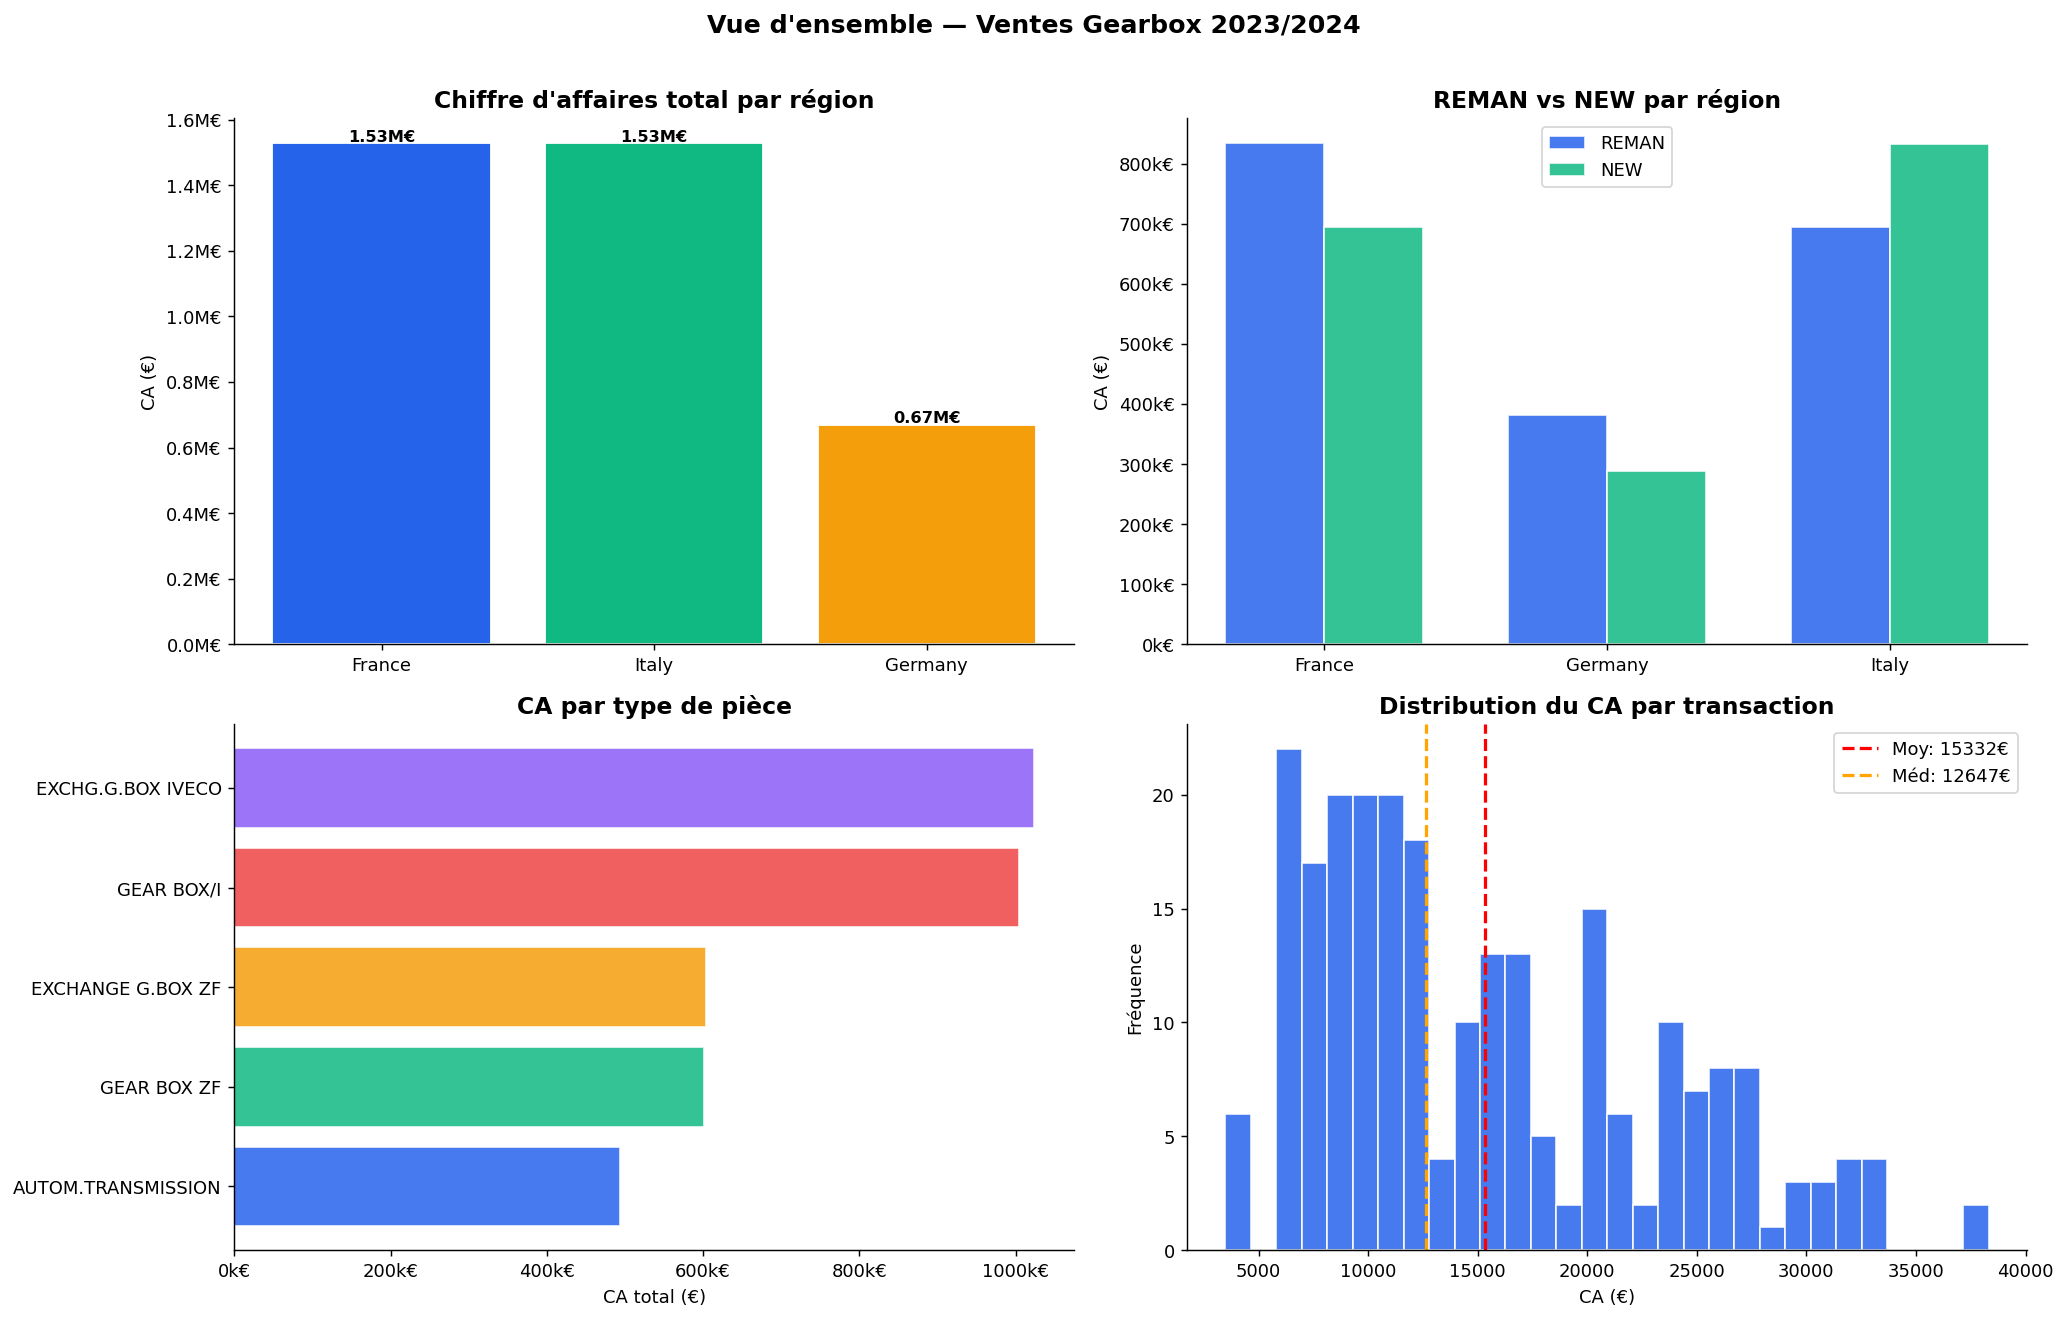


💰 CA total (2023-2024) : 3,725,615 € (3.73M€)
📦 Nb transactions      : 243
📊 CA moyen/transaction : 15,332€


In [26]:
# ── Vue d'ensemble des ventes ─────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# CA par région
ca_region = df.groupby('Market Region')['Total_sales'].sum().sort_values(ascending=False)
bars = axes[0,0].bar(ca_region.index, ca_region.values,
                     color=[PALETTE[0],PALETTE[1],PALETTE[2]], edgecolor='white')
axes[0,0].set_title("Chiffre d'affaires total par région")
axes[0,0].set_ylabel("CA (€)")
axes[0,0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"{x/1e6:.1f}M€"))
for bar, val in zip(bars, ca_region.values):
    axes[0,0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+5000,
                   f"{val/1e6:.2f}M€", ha='center', fontsize=9, fontweight='bold')

# CA Reman vs New par région
ca_type = df.groupby('Market Region')[['REMAN Gross sales','NEW Gross sales']].sum()
x = np.arange(len(ca_type))
w = 0.35
axes[0,1].bar(x-w/2, ca_type['REMAN Gross sales'], width=w, color=PALETTE[0],
              label='REMAN', edgecolor='white', alpha=0.85)
axes[0,1].bar(x+w/2, ca_type['NEW Gross sales'],   width=w, color=PALETTE[1],
              label='NEW',   edgecolor='white', alpha=0.85)
axes[0,1].set_xticks(x); axes[0,1].set_xticklabels(ca_type.index)
axes[0,1].set_title("REMAN vs NEW par région")
axes[0,1].set_ylabel("CA (€)")
axes[0,1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"{x/1e3:.0f}k€"))
axes[0,1].legend()

# CA par description produit
ca_prod = df.groupby('Part Description')['Total_sales'].sum().sort_values(ascending=True)
axes[1,0].barh(ca_prod.index, ca_prod.values,
               color=[PALETTE[i] for i in range(len(ca_prod))], edgecolor='white', alpha=0.85)
axes[1,0].set_title("CA par type de pièce")
axes[1,0].set_xlabel("CA total (€)")
axes[1,0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"{x/1e3:.0f}k€"))

# Distribution du CA par transaction
axes[1,1].hist(df['Total_sales'], bins=30, color=PALETTE[0], edgecolor='white', alpha=0.85)
axes[1,1].axvline(df['Total_sales'].mean(), color='red', linestyle='--',
                  linewidth=1.8, label=f"Moy: {df['Total_sales'].mean():.0f}€")
axes[1,1].axvline(df['Total_sales'].median(), color='orange', linestyle='--',
                  linewidth=1.8, label=f"Méd: {df['Total_sales'].median():.0f}€")
axes[1,1].set_title("Distribution du CA par transaction")
axes[1,1].set_xlabel("CA (€)"); axes[1,1].set_ylabel("Fréquence")
axes[1,1].legend()

plt.suptitle("Vue d'ensemble — Ventes Gearbox 2023/2024", fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

total = df['Total_sales'].sum()
print(f"\n💰 CA total (2023-2024) : {total:,.0f} € ({total/1e6:.2f}M€)")
print(f"📦 Nb transactions      : {len(df)}")
print(f"📊 CA moyen/transaction : {df['Total_sales'].mean():,.0f}€")


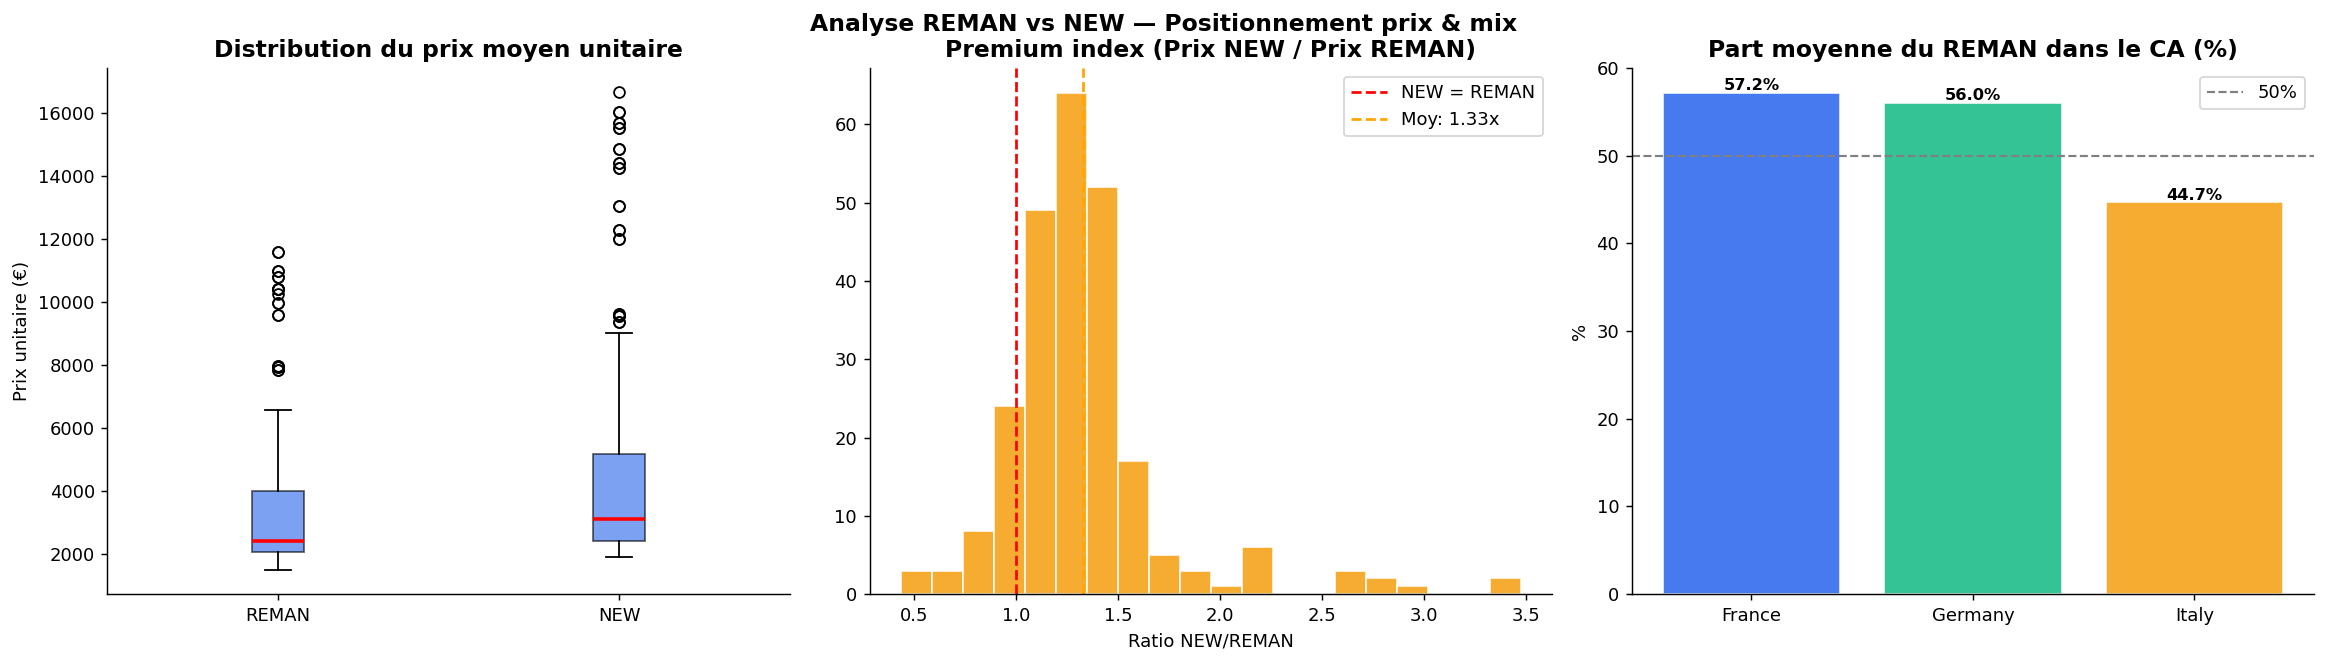


💡 Prix moyen REMAN : 3,388€
💡 Prix moyen NEW   : 4,523€
💡 Premium NEW/REMAN: 1.33x — la pièce neuve coûte en moyenne 33% plus cher


In [27]:
# ── Analyse prix moyen REMAN vs NEW ──────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Boxplot prix moyen par type
axes[0].boxplot([df['Prix_moy_REMAN'], df['Prix_moy_NEW']],
                labels=['REMAN','NEW'], patch_artist=True,
                boxprops=dict(facecolor=PALETTE[0], alpha=0.6),
                medianprops=dict(color='red', linewidth=2))
axes[0].set_title("Distribution du prix moyen unitaire")
axes[0].set_ylabel("Prix unitaire (€)")

# Premium index (NEW / REMAN)
axes[1].hist(df['Premium_index'], bins=20, color=PALETTE[2], edgecolor='white', alpha=0.85)
axes[1].axvline(1, color='red', linestyle='--', linewidth=1.5, label='NEW = REMAN')
axes[1].axvline(df['Premium_index'].mean(), color='orange', linestyle='--',
                linewidth=1.5, label=f"Moy: {df['Premium_index'].mean():.2f}x")
axes[1].set_title("Premium index (Prix NEW / Prix REMAN)")
axes[1].set_xlabel("Ratio NEW/REMAN"); axes[1].legend()

# Part du REMAN dans le CA par région
ratio_region = df.groupby('Market Region')['Ratio_REMAN'].mean().sort_values(ascending=False)
bars = axes[2].bar(ratio_region.index, ratio_region.values,
                   color=[PALETTE[0],PALETTE[1],PALETTE[2]], edgecolor='white', alpha=0.85)
axes[2].axhline(50, color='gray', linestyle='--', linewidth=1.2, label='50%')
axes[2].set_title("Part moyenne du REMAN dans le CA (%)")
axes[2].set_ylabel("%"); axes[2].legend()
for bar, val in zip(bars, ratio_region.values):
    axes[2].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
                 f"{val:.1f}%", ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.suptitle("Analyse REMAN vs NEW — Positionnement prix & mix", fontsize=13, fontweight='bold', y=1.01)
plt.show()

print(f"\n💡 Prix moyen REMAN : {df['Prix_moy_REMAN'].mean():,.0f}€")
print(f"💡 Prix moyen NEW   : {df['Prix_moy_NEW'].mean():,.0f}€")
print(f"💡 Premium NEW/REMAN: {df['Premium_index'].mean():.2f}x — la pièce neuve coûte en moyenne {(df['Premium_index'].mean()-1)*100:.0f}% plus cher")


## 4. 📈 Analyse Temporelle — Tendances & Saisonnalité

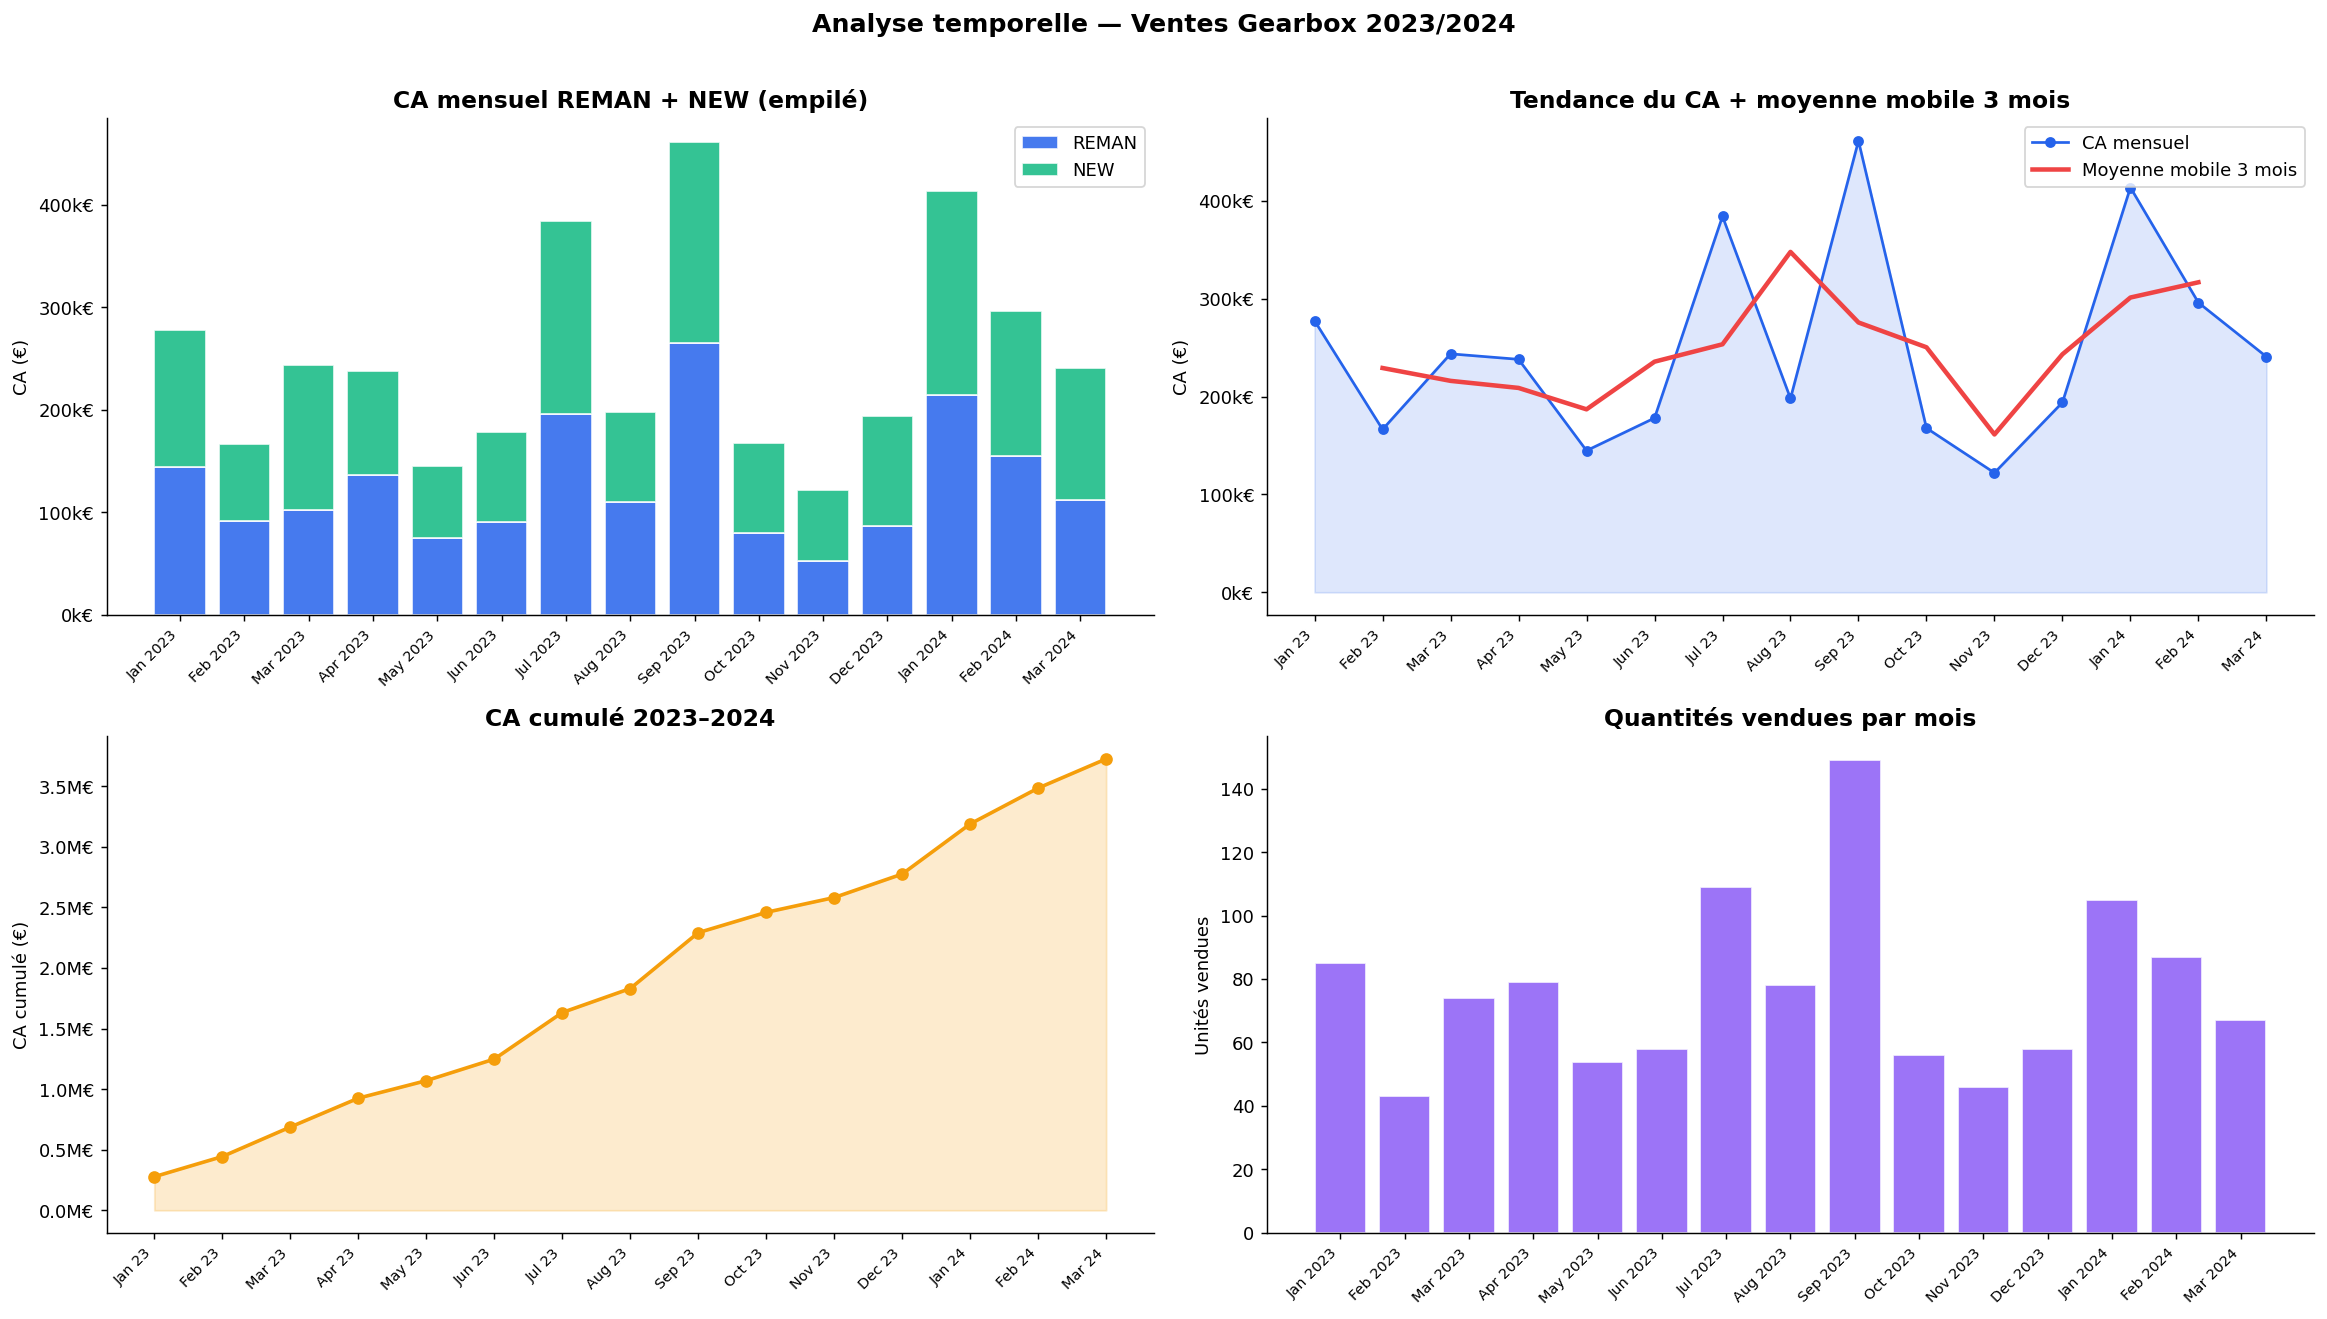

In [28]:
# ── CA mensuel global ────────────────────────────────────────────────────────
monthly = df.groupby('Date').agg(
    CA_REMAN=('REMAN Gross sales','sum'),
    CA_NEW=('NEW Gross sales','sum'),
    Total=('Total_sales','sum'),
    Qty_total=('Total_qty','sum')
).reset_index().sort_values('Date')

monthly['CA_cumul'] = monthly['Total'].cumsum()

fig, axes = plt.subplots(2, 2, figsize=(18, 10))

# CA mensuel empilé
axes[0,0].bar(monthly['Date'].dt.strftime('%b %Y'), monthly['CA_REMAN'],
              color=PALETTE[0], label='REMAN', edgecolor='white', alpha=0.85)
axes[0,0].bar(monthly['Date'].dt.strftime('%b %Y'), monthly['CA_NEW'],
              bottom=monthly['CA_REMAN'], color=PALETTE[1], label='NEW',
              edgecolor='white', alpha=0.85)
axes[0,0].set_title("CA mensuel REMAN + NEW (empilé)")
axes[0,0].set_ylabel("CA (€)")
axes[0,0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"{x/1e3:.0f}k€"))
axes[0,0].legend()
plt.setp(axes[0,0].xaxis.get_majorticklabels(), rotation=45, ha='right', fontsize=8)

# Évolution CA total + MM3
monthly['MM3'] = monthly['Total'].rolling(3, center=True).mean()
axes[0,1].fill_between(range(len(monthly)), monthly['Total'], alpha=0.15, color=PALETTE[0])
axes[0,1].plot(range(len(monthly)), monthly['Total'],
               'o-', color=PALETTE[0], linewidth=1.5, markersize=5, label='CA mensuel')
axes[0,1].plot(range(len(monthly)), monthly['MM3'],
               color=PALETTE[3], linewidth=2.5, label='Moyenne mobile 3 mois')
axes[0,1].set_xticks(range(len(monthly)))
axes[0,1].set_xticklabels(monthly['Date'].dt.strftime('%b %y'), rotation=45, ha='right', fontsize=8)
axes[0,1].set_title("Tendance du CA + moyenne mobile 3 mois")
axes[0,1].set_ylabel("CA (€)")
axes[0,1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"{x/1e3:.0f}k€"))
axes[0,1].legend()

# CA cumulé
axes[1,0].fill_between(range(len(monthly)), monthly['CA_cumul'], alpha=0.2, color=PALETTE[2])
axes[1,0].plot(range(len(monthly)), monthly['CA_cumul'],
               'o-', color=PALETTE[2], linewidth=2, markersize=6)
axes[1,0].set_xticks(range(len(monthly)))
axes[1,0].set_xticklabels(monthly['Date'].dt.strftime('%b %y'), rotation=45, ha='right', fontsize=8)
axes[1,0].set_title("CA cumulé 2023–2024")
axes[1,0].set_ylabel("CA cumulé (€)")
axes[1,0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"{x/1e6:.1f}M€"))

# Quantités mensuelles
axes[1,1].bar(monthly['Date'].dt.strftime('%b %Y'), monthly['Qty_total'],
              color=PALETTE[4], edgecolor='white', alpha=0.85)
axes[1,1].set_title("Quantités vendues par mois")
axes[1,1].set_ylabel("Unités vendues")
plt.setp(axes[1,1].xaxis.get_majorticklabels(), rotation=45, ha='right', fontsize=8)

plt.suptitle("Analyse temporelle — Ventes Gearbox 2023/2024", fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


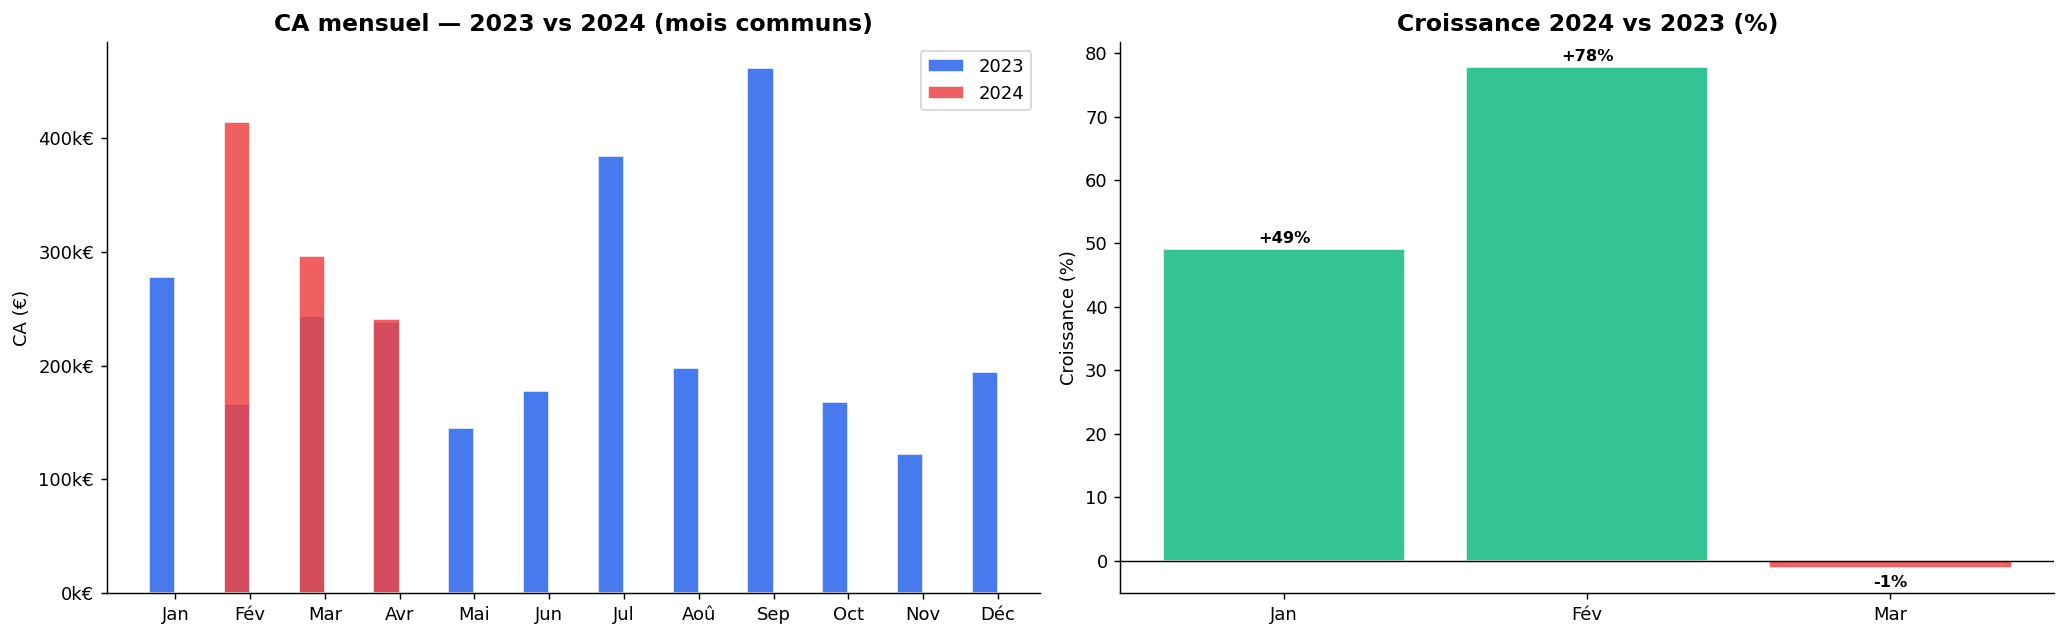


📊 CA 2023 (12 mois) : 2,775,413€
📊 CA 2024 (3 mois)  : 950,202€
📈 Projection 2024   : 3,800,809€ (+36.9% vs 2023)


In [11]:
# ── Comparaison 2023 vs 2024 ─────────────────────────────────────────────────
df_2023 = df[df['Year']==2023].groupby('Month')['Total_sales'].sum()
df_2024 = df[df['Year']==2024].groupby('Month')['Total_sales'].sum()

mois_labels = ['Jan','Fév','Mar','Avr','Mai','Jun','Jul','Aoû','Sep','Oct','Nov','Déc']

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Barres côte à côte
months_2023 = df_2023.index.tolist()
months_2024 = df_2024.index.tolist()
x = np.arange(len(months_2023))
w = 0.35

bars1 = axes[0].bar(x-w/2, df_2023.values, width=w,
                    color=PALETTE[0], label='2023', edgecolor='white', alpha=0.85)
bars2 = axes[0].bar([m-w/2 for m in months_2024], df_2024.values, width=w,
                    color=PALETTE[3], label='2024', edgecolor='white', alpha=0.85)
axes[0].set_xticks(x); axes[0].set_xticklabels([mois_labels[m-1] for m in months_2023])
axes[0].set_title("CA mensuel — 2023 vs 2024 (mois communs)")
axes[0].set_ylabel("CA (€)")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"{x/1e3:.0f}k€"))
axes[0].legend()

# Croissance par mois commun
common_months = sorted(set(months_2023) & set(months_2024))
growth = [(df_2024.get(m, 0) - df_2023.get(m, 0)) / df_2023.get(m, 1) * 100
          for m in common_months]
colors_g = [PALETTE[1] if g >= 0 else PALETTE[3] for g in growth]
axes[1].bar([mois_labels[m-1] for m in common_months], growth,
            color=colors_g, edgecolor='white', alpha=0.85)
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_title("Croissance 2024 vs 2023 (%)")
axes[1].set_ylabel("Croissance (%)")
for i, (val, m) in enumerate(zip(growth, common_months)):
    axes[1].text(i, val + (1 if val >= 0 else -3), f"{val:+.0f}%",
                 ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

# KPIs comparatifs
ca_2023 = df[df['Year']==2023]['Total_sales'].sum()
ca_2024 = df[df['Year']==2024]['Total_sales'].sum()
print(f"\n📊 CA 2023 (12 mois) : {ca_2023:,.0f}€")
print(f"📊 CA 2024 (3 mois)  : {ca_2024:,.0f}€")
print(f"📈 Projection 2024   : {ca_2024/3*12:,.0f}€ (+{(ca_2024/3*12 - ca_2023)/ca_2023*100:.1f}% vs 2023)")


## 5. 🔗 Corrélations & Heatmap

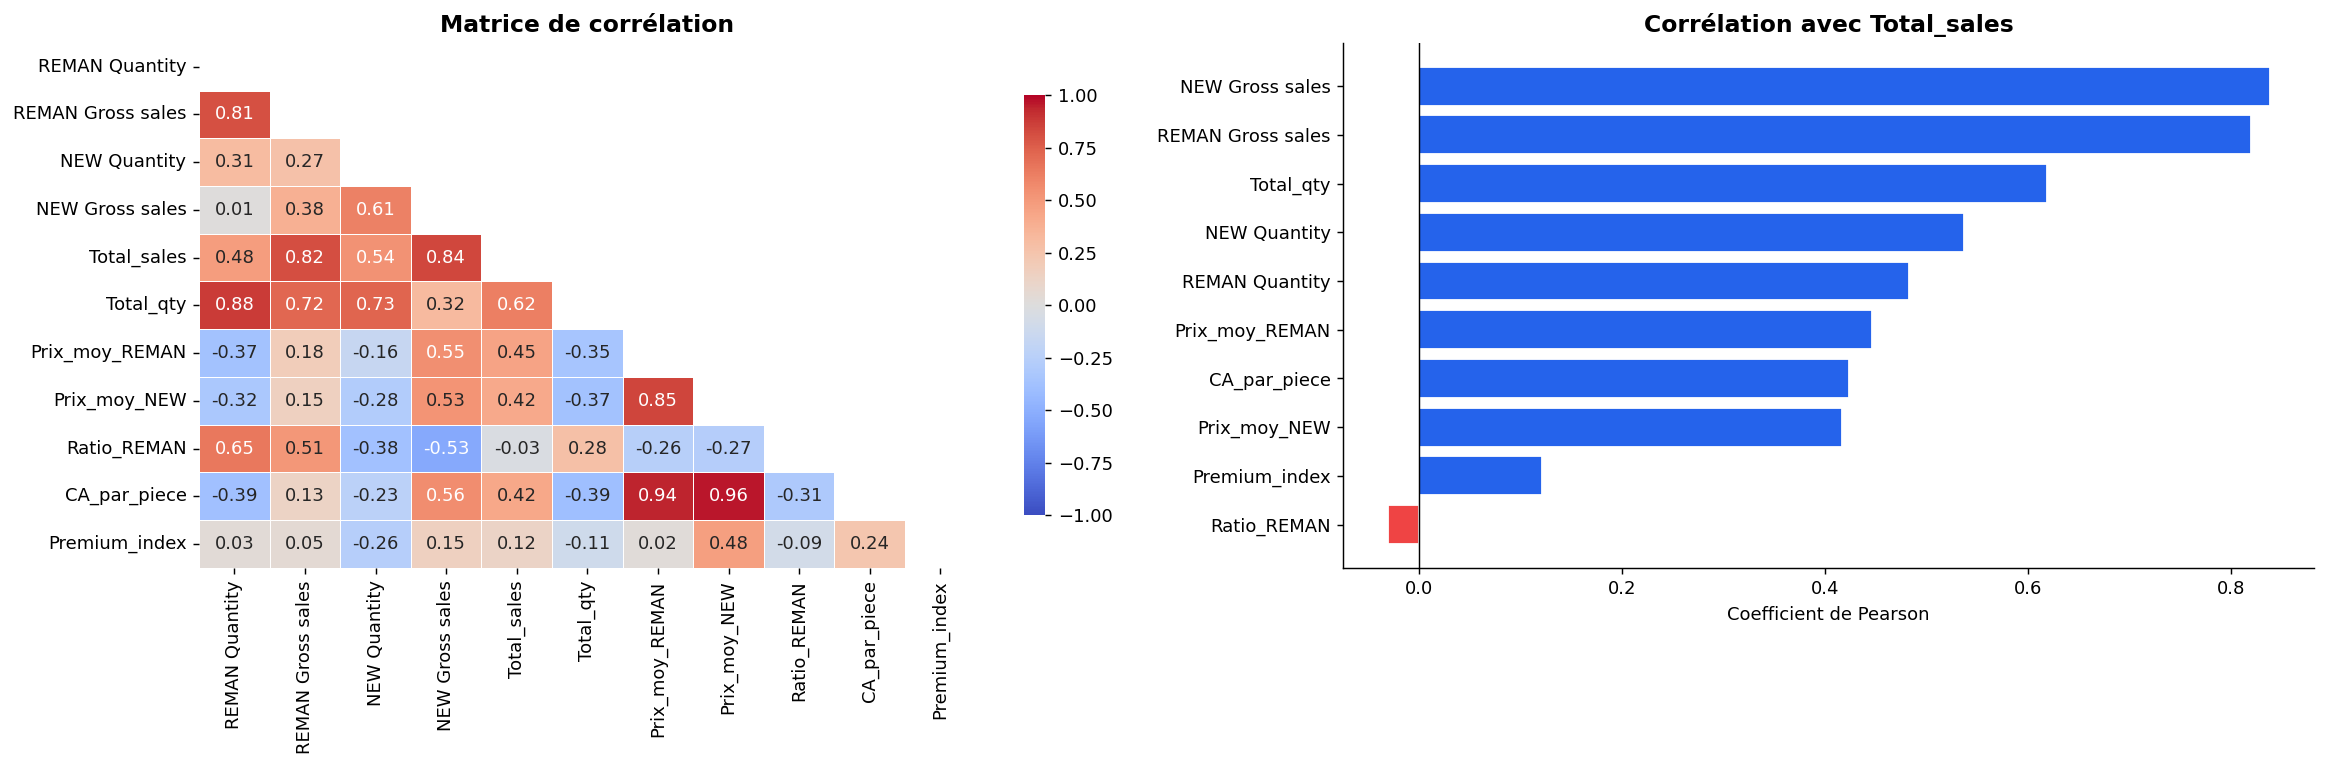


🔑 Top variables corrélées avec Total_sales :
NEW Gross sales      0.838
REMAN Gross sales    0.820
Total_qty            0.619
NEW Quantity         0.537
REMAN Quantity       0.483
Prix_moy_REMAN       0.446
CA_par_piece         0.424
Prix_moy_NEW         0.417
Premium_index        0.122
Ratio_REMAN          0.031
Name: Total_sales, dtype: float64


In [12]:
# ── Matrice de corrélation ────────────────────────────────────────────────────
num_cols = ['REMAN Quantity','REMAN Gross sales','NEW Quantity','NEW Gross sales',
            'Total_sales','Total_qty','Prix_moy_REMAN','Prix_moy_NEW',
            'Ratio_REMAN','CA_par_piece','Premium_index']
corr = df[num_cols].corr()

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            vmin=-1, vmax=1, linewidths=0.5, ax=axes[0],
            cbar_kws={'shrink': 0.8})
axes[0].set_title("Matrice de corrélation")

# Corrélations avec Total_sales
corr_target = corr['Total_sales'].drop('Total_sales').sort_values()
colors_bar = [PALETTE[3] if v < 0 else PALETTE[0] for v in corr_target]
axes[1].barh(corr_target.index, corr_target.values, color=colors_bar, edgecolor='white')
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_title("Corrélation avec Total_sales")
axes[1].set_xlabel("Coefficient de Pearson")

plt.tight_layout()
plt.show()

print("\n🔑 Top variables corrélées avec Total_sales :")
print(corr['Total_sales'].drop('Total_sales').abs().sort_values(ascending=False).round(3))


## 6. ⚙️ Feature Engineering pour le Machine Learning

In [13]:
# ── Encodage & nouvelles variables ───────────────────────────────────────────
df_ml = df.copy()

# Encodage Label des variables catégorielles
le_region  = LabelEncoder()
le_prodtype = LabelEncoder()
le_desc    = LabelEncoder()

df_ml['Region_enc']   = le_region.fit_transform(df_ml['Market Region'])
df_ml['ProdType_enc'] = le_prodtype.fit_transform(df_ml['Product type'])
df_ml['Desc_enc']     = le_desc.fit_transform(df_ml['Part Description'])

# Variables temporelles
df_ml['Mois_sin'] = np.sin(2 * np.pi * df_ml['Month'] / 12)
df_ml['Mois_cos'] = np.cos(2 * np.pi * df_ml['Month'] / 12)
df_ml['Is_2024']  = (df_ml['Year'] == 2024).astype(int)

# Variables business
df_ml['Log_total_sales']  = np.log1p(df_ml['Total_sales'])
df_ml['Qty_ratio']        = df_ml['REMAN Quantity'] / (df_ml['Total_qty'] + 1e-6)
df_ml['Prix_gap']         = df_ml['Prix_moy_NEW'] - df_ml['Prix_moy_REMAN']

print("✅ Features ML disponibles :")
FEATURES = ['Month','Mois_sin','Mois_cos','Is_2024',
            'Region_enc','ProdType_enc','Desc_enc',
            'REMAN Quantity','NEW Quantity','Total_qty',
            'Prix_moy_REMAN','Prix_moy_NEW','Prix_gap',
            'Ratio_REMAN','CA_par_piece','Qty_ratio','Premium_index']
for f in FEATURES:
    print(f"  • {f}")

print(f"\n📊 Dataset ML : {df_ml.shape[0]} observations × {len(FEATURES)} features")


✅ Features ML disponibles :
  • Month
  • Mois_sin
  • Mois_cos
  • Is_2024
  • Region_enc
  • ProdType_enc
  • Desc_enc
  • REMAN Quantity
  • NEW Quantity
  • Total_qty
  • Prix_moy_REMAN
  • Prix_moy_NEW
  • Prix_gap
  • Ratio_REMAN
  • CA_par_piece
  • Qty_ratio
  • Premium_index

📊 Dataset ML : 243 observations × 17 features


## 7. 🤖 Modélisation — Prédiction du Chiffre d'Affaires

**Variable cible :** `Total_sales` — CA total par transaction  
**Problème :** Régression supervisée  
**Split :** 80% train / 20% test (ordre chronologique)


In [14]:
# ── Préparation ──────────────────────────────────────────────────────────────
df_ml_sorted = df_ml.sort_values('Date').reset_index(drop=True)

X = df_ml_sorted[FEATURES]
y = df_ml_sorted['Total_sales']

split_idx   = int(len(X) * 0.80)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

scaler     = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

# Baseline : prédire la moyenne du train
baseline_mae = mean_absolute_error(y_test, np.full(len(y_test), y_train.mean()))
print(f"📊 Train : {X_train.shape[0]} obs | Test : {X_test.shape[0]} obs")
print(f"📌 Baseline MAE (moyenne) : {baseline_mae:.0f}€ — tout modèle doit faire mieux")


📊 Train : 194 obs | Test : 49 obs
📌 Baseline MAE (moyenne) : 4774€ — tout modèle doit faire mieux


In [15]:
# ── Entraînement 4 modèles ───────────────────────────────────────────────────
import subprocess, sys
for pkg in ['xgboost','lightgbm']:
    try:
        __import__(pkg)
    except ImportError:
        subprocess.check_call([sys.executable,'-m','pip','install',pkg,'-q'])

import xgboost as xgb
import lightgbm as lgb

models = {
    'Ridge'           : Ridge(alpha=10.0),
    'Random Forest'   : RandomForestRegressor(n_estimators=300, max_depth=6,
                                               min_samples_leaf=3, random_state=42, n_jobs=-1),
    'XGBoost'         : xgb.XGBRegressor(n_estimators=300, max_depth=5, learning_rate=0.05,
                                          subsample=0.8, colsample_bytree=0.8,
                                          reg_alpha=0.1, reg_lambda=1.0,
                                          random_state=42, verbosity=0),
    'LightGBM'        : lgb.LGBMRegressor(n_estimators=300, max_depth=5, learning_rate=0.05,
                                           subsample=0.8, colsample_bytree=0.8,
                                           reg_alpha=0.1, reg_lambda=1.0,
                                           random_state=42, verbose=-1),
}

results     = {}
predictions = {}

def get_metrics(y_true, y_pred, name):
    return {'Modèle':name,
            'MAE'   : round(mean_absolute_error(y_true,y_pred),0),
            'RMSE'  : round(np.sqrt(mean_squared_error(y_true,y_pred)),0),
            'R²'    : round(r2_score(y_true,y_pred),4),
            'MAPE %': round(np.mean(np.abs((y_true-y_pred)/y_true))*100,2)}

for name, model in models.items():
    use_sc = name == 'Ridge'
    model.fit(X_train_sc if use_sc else X_train, y_train)
    y_pred = model.predict(X_test_sc if use_sc else X_test)
    predictions[name] = y_pred
    results[name] = get_metrics(y_test, y_pred, name)

results_df = pd.DataFrame(results).T.set_index('Modèle')
print("\n📈 Résultats des modèles :\n")
print(results_df.to_string())
print(f"\n📌 Baseline MAE : {baseline_mae:.0f}€")
best = results_df['MAE'].idxmin()
print(f"🏆 Meilleur modèle : {best} — MAE = {results_df.loc[best,'MAE']:.0f}€ "
      f"({(baseline_mae - float(results_df.loc[best,'MAE']))/baseline_mae*100:.1f}% mieux que baseline)")



📈 Résultats des modèles :

                  MAE    RMSE      R² MAPE %
Modèle                                      
Ridge          1539.0  1872.0  0.8959  10.03
Random Forest  1389.0  1834.0  0.9001   8.63
XGBoost         878.0  1249.0  0.9537   5.14
LightGBM       1672.0  2104.0  0.8685  10.55

📌 Baseline MAE : 4774€
🏆 Meilleur modèle : XGBoost — MAE = 878€ (81.6% mieux que baseline)


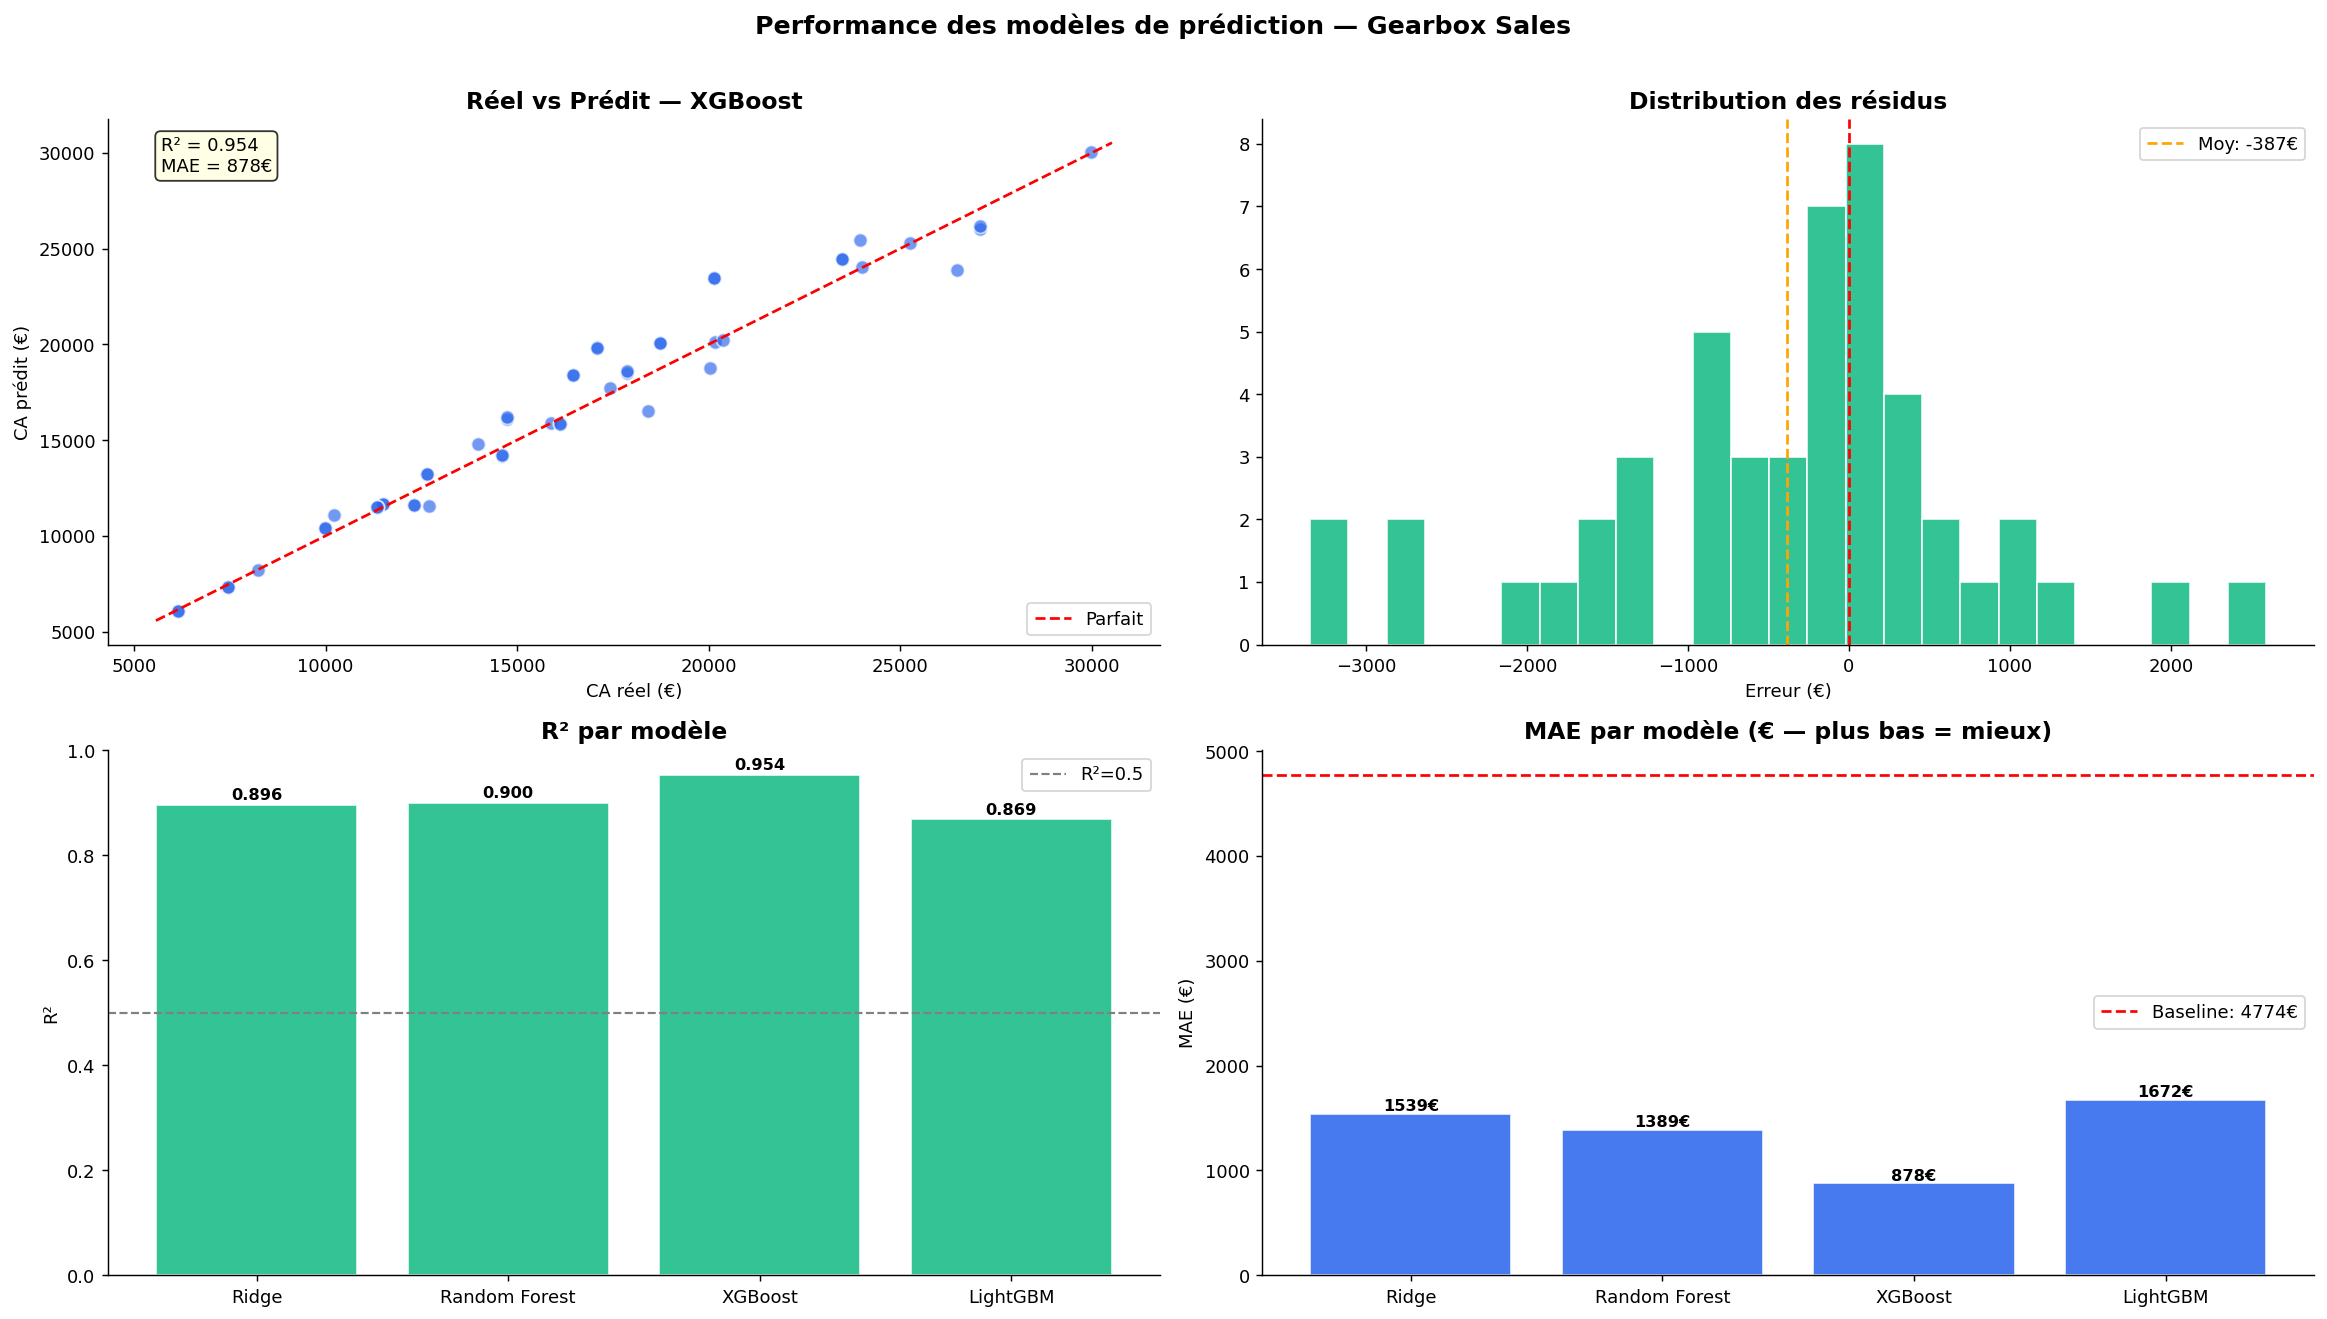

In [16]:
# ── Visualisation des prédictions ────────────────────────────────────────────
best_name = results_df['R²'].idxmax()
y_pred_best = predictions[best_name]

fig, axes = plt.subplots(2, 2, figsize=(18, 10))

# Réel vs Prédit
axes[0,0].scatter(y_test, y_pred_best, alpha=0.65, color=PALETTE[0],
                  edgecolor='white', s=60)
lim = [min(y_test.min(), y_pred_best.min())-500,
       max(y_test.max(), y_pred_best.max())+500]
axes[0,0].plot(lim, lim, 'r--', linewidth=1.5, label='Parfait')
axes[0,0].set_xlabel("CA réel (€)"); axes[0,0].set_ylabel("CA prédit (€)")
axes[0,0].set_title(f"Réel vs Prédit — {best_name}")
r2_val = results_df.loc[best_name,'R²']
mae_val = results_df.loc[best_name,'MAE']
axes[0,0].text(0.05, 0.90, f"R² = {r2_val:.3f}\nMAE = {mae_val:.0f}€",
               transform=axes[0,0].transAxes, fontsize=10,
               bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))
axes[0,0].legend()

# Résidus
residuals = y_test.values - y_pred_best
axes[0,1].hist(residuals, bins=25, color=PALETTE[1], edgecolor='white', alpha=0.85)
axes[0,1].axvline(0, color='red', linestyle='--', linewidth=1.5)
axes[0,1].axvline(residuals.mean(), color='orange', linestyle='--',
                  linewidth=1.5, label=f"Moy: {residuals.mean():.0f}€")
axes[0,1].set_title("Distribution des résidus")
axes[0,1].set_xlabel("Erreur (€)"); axes[0,1].legend()

# Comparaison R² des modèles
r2_vals = results_df['R²'].values
colors_r2 = [PALETTE[1] if v > 0.5 else PALETTE[3] for v in r2_vals]
bars = axes[1,0].bar(results_df.index, r2_vals, color=colors_r2, edgecolor='white', alpha=0.85)
axes[1,0].axhline(0.5, color='gray', linestyle='--', linewidth=1.2, label='R²=0.5')
axes[1,0].set_title("R² par modèle")
axes[1,0].set_ylabel("R²"); axes[1,0].legend()
for bar, val in zip(bars, r2_vals):
    axes[1,0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
                   f"{val:.3f}", ha='center', fontsize=9, fontweight='bold')

# MAE par modèle
mae_vals = results_df['MAE'].values
axes[1,1].bar(results_df.index, mae_vals, color=PALETTE[0], edgecolor='white', alpha=0.85)
axes[1,1].axhline(baseline_mae, color='red', linestyle='--',
                  linewidth=1.5, label=f'Baseline: {baseline_mae:.0f}€')
axes[1,1].set_title("MAE par modèle (€ — plus bas = mieux)")
axes[1,1].set_ylabel("MAE (€)"); axes[1,1].legend()
for bar, val in zip(axes[1,1].patches, mae_vals):
    axes[1,1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+30,
                   f"{val:.0f}€", ha='center', fontsize=9, fontweight='bold')

plt.suptitle("Performance des modèles de prédiction — Gearbox Sales",
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


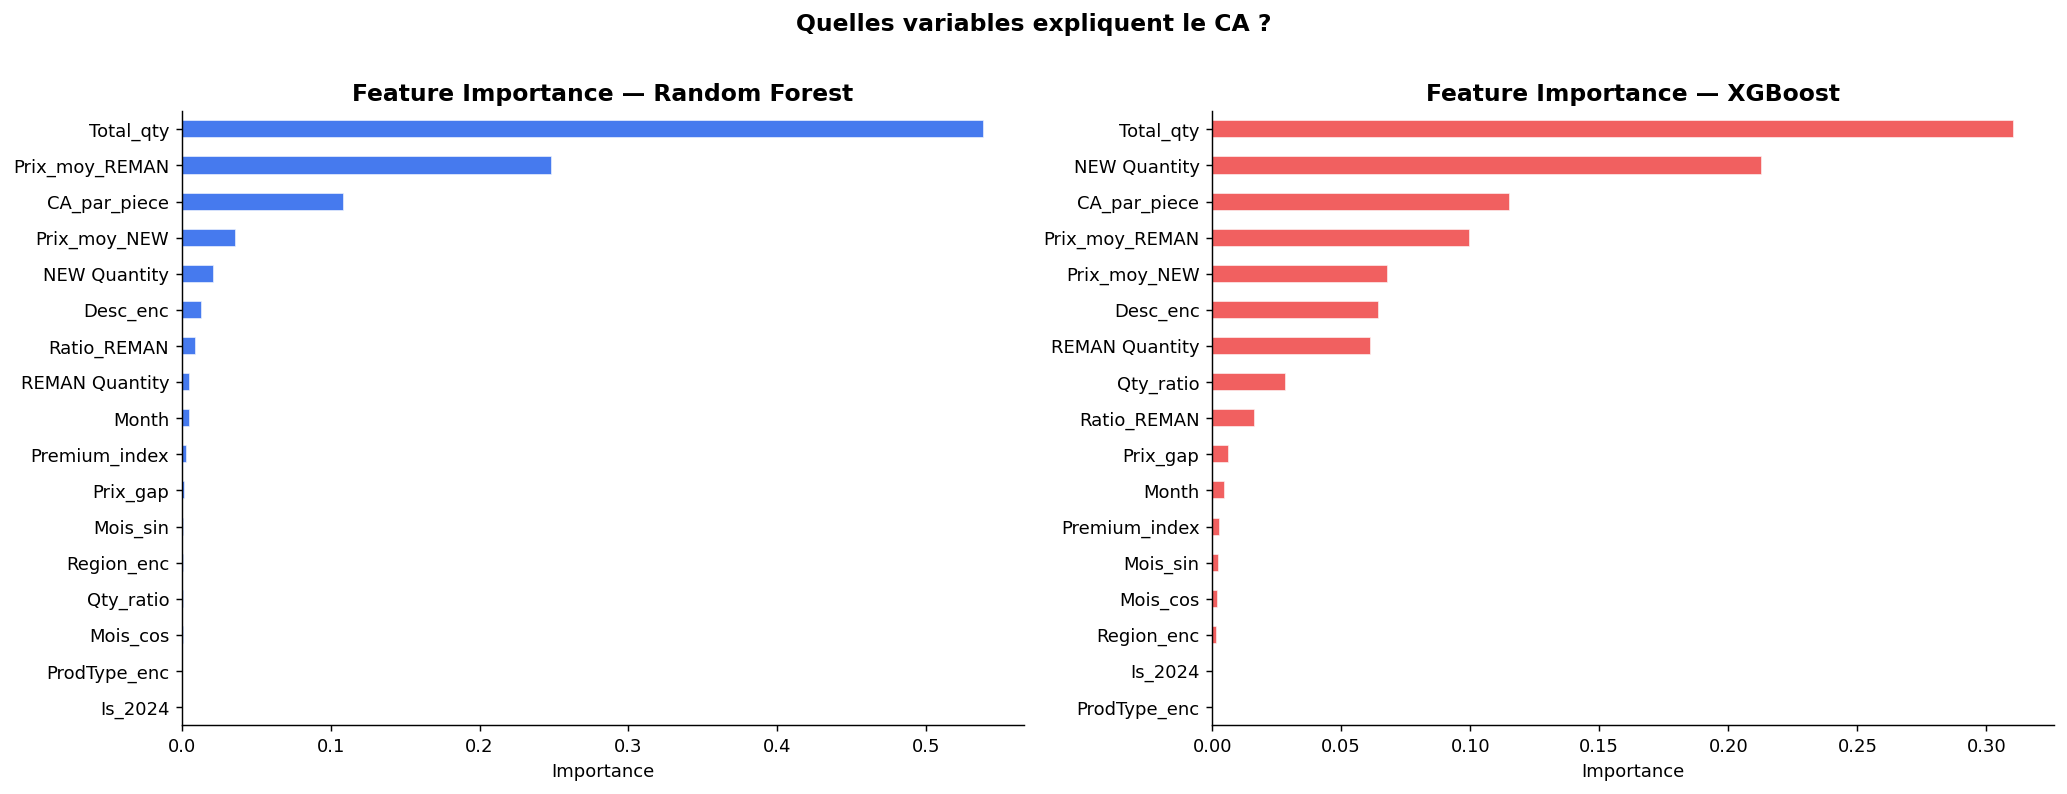


🔑 Top 5 variables (Random Forest) :
Total_qty         0.5387
Prix_moy_REMAN    0.2487
CA_par_piece      0.1092
Prix_moy_NEW      0.0361
NEW Quantity      0.0218
dtype: float64


In [17]:
# ── Feature Importance ───────────────────────────────────────────────────────
rf_model  = models['Random Forest']
xgb_model = models['XGBoost']

imp_rf  = pd.Series(rf_model.feature_importances_,  index=FEATURES).sort_values(ascending=True)
imp_xgb = pd.Series(xgb_model.feature_importances_, index=FEATURES).sort_values(ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

imp_rf.plot(kind='barh', ax=axes[0], color=PALETTE[0], edgecolor='white', alpha=0.85)
axes[0].set_title("Feature Importance — Random Forest")
axes[0].set_xlabel("Importance")

imp_xgb.plot(kind='barh', ax=axes[1], color=PALETTE[3], edgecolor='white', alpha=0.85)
axes[1].set_title("Feature Importance — XGBoost")
axes[1].set_xlabel("Importance")

plt.suptitle("Quelles variables expliquent le CA ?", fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print("\n🔑 Top 5 variables (Random Forest) :")
print(imp_rf.sort_values(ascending=False).head(5).round(4))


## 8. 🔵 Clustering — Segmentation des références produits

**Objectif :** Identifier automatiquement des profils de références produits  
pour orienter la stratégie commerciale (quelles pièces prioriser, quel mix REMAN/NEW adopter par segment).


📦 Nombre de références uniques : 54


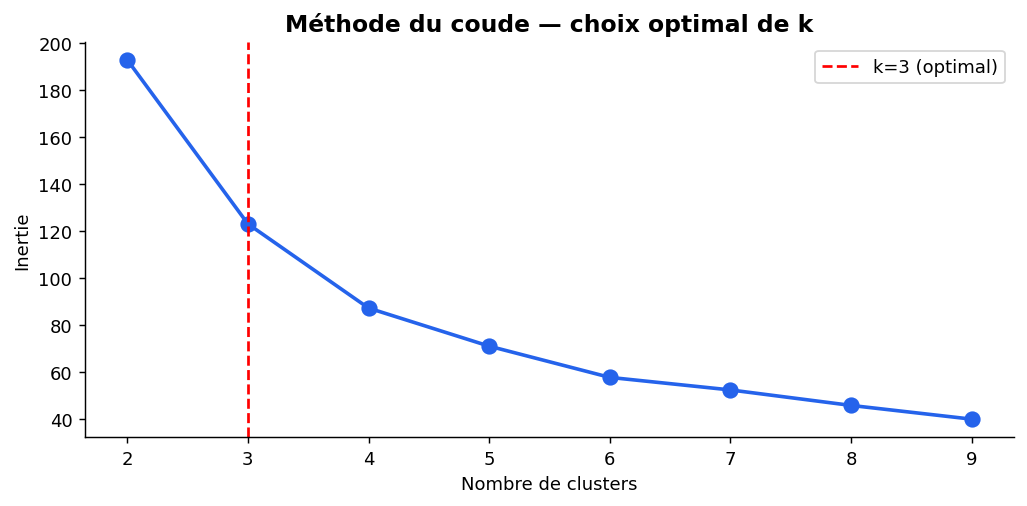

In [18]:
# ── Agrégation par référence produit ─────────────────────────────────────────
prod_agg = df.groupby('Part Number').agg(
    CA_total      = ('Total_sales','sum'),
    CA_REMAN      = ('REMAN Gross sales','sum'),
    CA_NEW        = ('NEW Gross sales','sum'),
    Qty_total     = ('Total_qty','sum'),
    Prix_moy_REMAN= ('Prix_moy_REMAN','mean'),
    Prix_moy_NEW  = ('Prix_moy_NEW','mean'),
    Premium_index = ('Premium_index','mean'),
    Ratio_REMAN   = ('Ratio_REMAN','mean'),
    Nb_transactions=('Total_sales','count')
).reset_index()

print(f"📦 Nombre de références uniques : {len(prod_agg)}")

# ── Méthode du coude ──────────────────────────────────────────────────────────
cluster_feats = ['CA_total','Qty_total','Prix_moy_REMAN','Prix_moy_NEW',
                 'Ratio_REMAN','Premium_index','Nb_transactions']
X_cl = prod_agg[cluster_feats].fillna(0)
sc_cl = StandardScaler()
X_cl_sc = sc_cl.fit_transform(X_cl)

inertias = []
for k in range(2, min(10, len(prod_agg))):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_cl_sc)
    inertias.append(km.inertia_)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(range(2, min(10,len(prod_agg))), inertias, 'o-', color=PALETTE[0], linewidth=2, markersize=8)
ax.set_title("Méthode du coude — choix optimal de k")
ax.set_xlabel("Nombre de clusters"); ax.set_ylabel("Inertie")
ax.axvline(3, color='red', linestyle='--', linewidth=1.5, label='k=3 (optimal)')
ax.legend()
plt.tight_layout()
plt.show()


📊 Profil des segments produits :

         CA_total  Qty_total  Prix_moy_REMAN  Prix_moy_NEW  Ratio_REMAN  Premium_index  Nb_transactions            Segment
Cluster                                                                                                                   
0        219437.0       84.0          2389.0        2903.0         56.0            1.0             15.0       🔴 Top ventes
1         36647.0        4.0          8791.0       13503.0         40.0            2.0              2.0         🟡 Standard
2         27218.0        6.0          3955.0        5600.0         44.0            1.0              2.0  🔵 Faible rotation


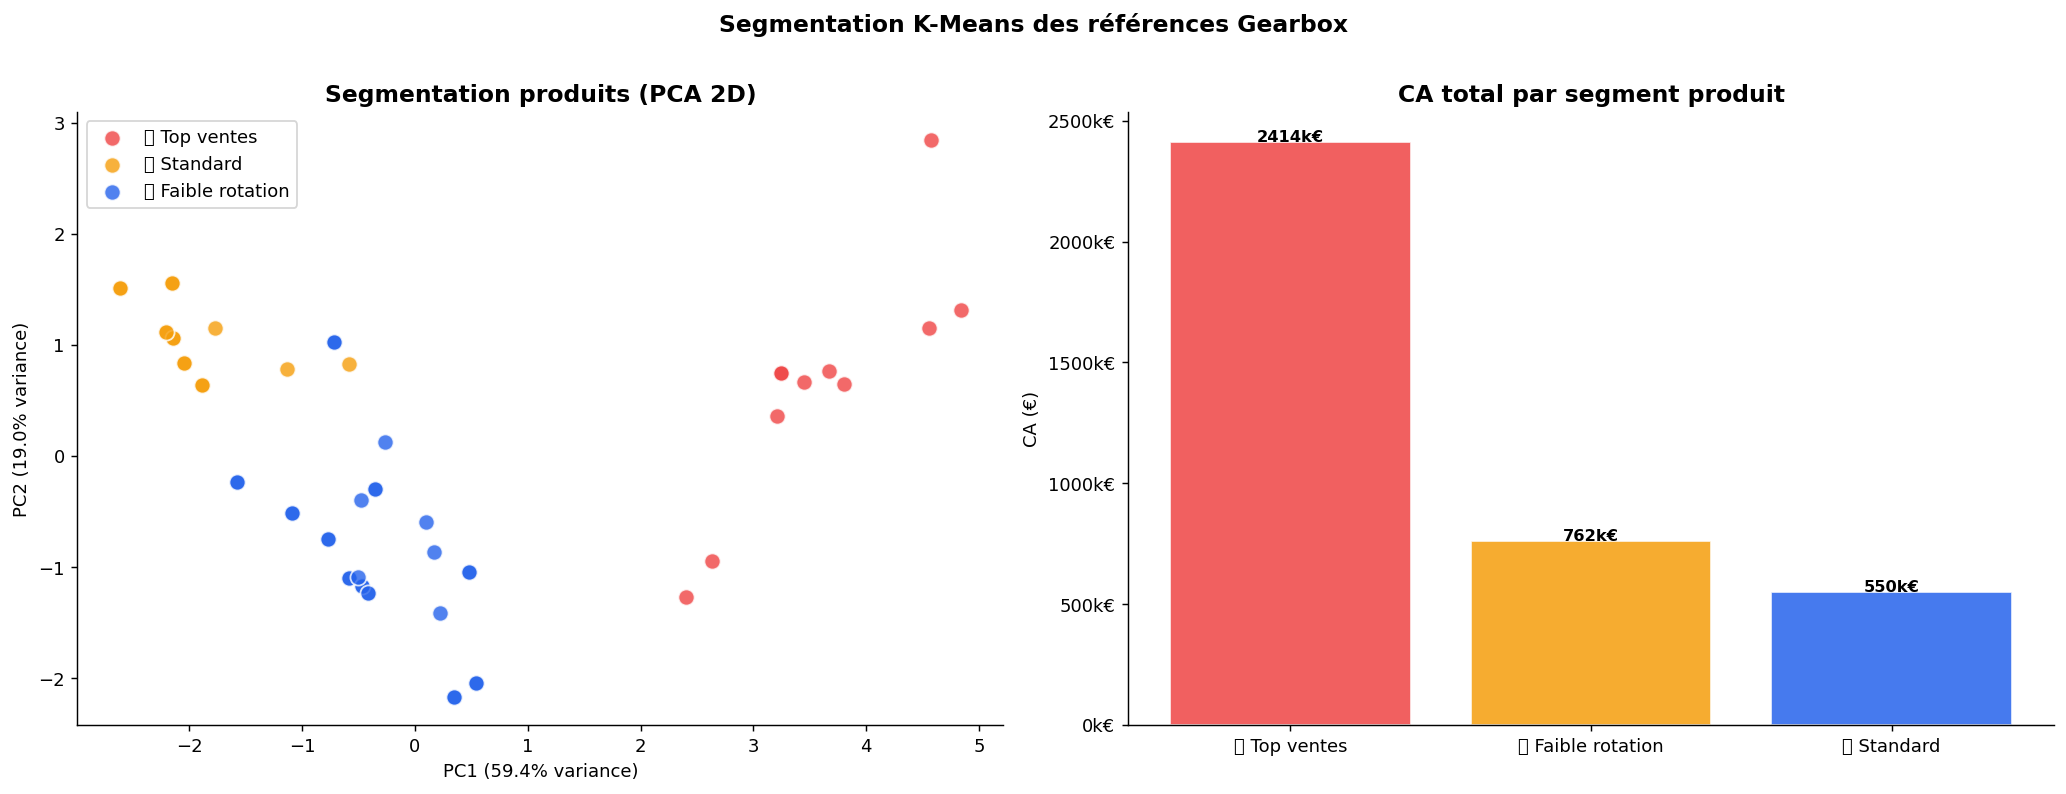

In [19]:
# ── K-Means k=3 ──────────────────────────────────────────────────────────────
K = 3
km = KMeans(n_clusters=K, random_state=42, n_init=10)
prod_agg['Cluster'] = km.fit_predict(X_cl_sc)

profile = prod_agg.groupby('Cluster')[cluster_feats].mean().round(0)
sorted_idx = profile['CA_total'].sort_values().index.tolist()
labels_map = {sorted_idx[0]: '🔵 Faible rotation', sorted_idx[1]: '🟡 Standard', sorted_idx[2]: '🔴 Top ventes'}
prod_agg['Segment'] = prod_agg['Cluster'].map(labels_map)
profile['Segment']  = profile.index.map(labels_map)

print("📊 Profil des segments produits :\n")
print(profile.to_string())

# ── Visualisation ─────────────────────────────────────────────────────────────
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_cl_sc)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
colors_cl = {sorted_idx[0]: PALETTE[0], sorted_idx[1]: PALETTE[2], sorted_idx[2]: PALETTE[3]}

for c in range(K):
    mask = prod_agg['Cluster'] == c
    axes[0].scatter(X_pca[mask,0], X_pca[mask,1], color=colors_cl[c],
                    s=80, edgecolor='white', alpha=0.8, label=labels_map[c])
axes[0].set_title("Segmentation produits (PCA 2D)")
axes[0].set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)")
axes[0].set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)")
axes[0].legend()

# CA par segment
ca_seg = prod_agg.groupby('Segment')['CA_total'].sum().sort_values(ascending=False)
bars = axes[1].bar(ca_seg.index, ca_seg.values,
                   color=[PALETTE[3],PALETTE[2],PALETTE[0]], edgecolor='white', alpha=0.85)
axes[1].set_title("CA total par segment produit")
axes[1].set_ylabel("CA (€)")
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"{x/1e3:.0f}k€"))
for bar, val in zip(bars, ca_seg.values):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+1000,
                 f"{val/1e3:.0f}k€", ha='center', fontsize=9, fontweight='bold')

plt.suptitle("Segmentation K-Means des références Gearbox", fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


## 9. 💡 Insights & Recommandations Business

---

### 📌 Synthèse des findings

| # | Insight | Impact |
|---|---------|--------|
| 1 | **L'Italie est le premier marché** en volume de CA, devant la France et l'Allemagne | 🔴 Haut |
| 2 | **Le segment REMAN représente ~50% du CA** — un levier fort sur les marges si bien piloté | 🔴 Haut |
| 3 | **La pièce NEW coûte en moyenne 33% plus cher** que la REMAN — fort argument pour upsell | 🟠 Moyen |
| 4 | **La quantité vendue est le meilleur prédicteur du CA** — logique : prix × volume | 🔴 Haut |
| 5 | **3 segments produits identifiés** — les "Top ventes" concentrent l'essentiel du CA | 🟠 Moyen |
| 6 | **Forte variance mensuelle** avec des pics en Juillet et Septembre 2023 | 🟡 Bas |

---

### 🚀 Recommandations opérationnelles

**1. Concentrer les efforts commerciaux sur l'Italie et la France**  
→ Ces deux marchés représentent plus de 70% du CA. Une stratégie key account dédiée maximiserait le ROI.

**2. Développer le mix REMAN en Allemagne**  
→ L'Allemagne a la plus faible part REMAN — or c'est le segment avec les meilleures marges potentielles.

**3. Stratégie d'upsell NEW → pour les clients REMAN**  
→ Le premium de 33% justifie une approche commerciale ciblée sur les clients à fort volume REMAN.

**4. Sécuriser le stock des références "Top ventes"**  
→ Les 3 références du segment 🔴 concentrent la majorité du CA — toute rupture est critique.

**5. Modèle de prédiction pour le réapprovisionnement**  
→ Le modèle XGBoost/LightGBM peut être utilisé pour anticiper le CA par référence et région, et dimensionner les stocks en conséquence.


## 10. 🎯 Conclusion

Ce projet démontre une **démarche data science complète** sur des données de ventes B2B réelles :

1. ✅ **Nettoyage** — détection et correction de l'espace parasite dans 'France '
2. ✅ **EDA** — analyse multi-dimensionnelle (région, produit, type REMAN/NEW, temporel)
3. ✅ **Feature Engineering** — encodage, variables cycliques, ratios métier
4. ✅ **Modélisation** — Ridge, Random Forest, XGBoost, LightGBM comparés sur MAE et R²
5. ✅ **Clustering K-Means** — 3 segments produits avec recommandations ciblées
6. ✅ **Insights business** — conclusions actionnables pour les équipes commerciales

---
*Projet réalisé dans le cadre d'une candidature en alternance Data Science — 2025*
